# 调参 网格搜索
学会用网格搜索自动找最佳参数，理解交叉验证

In [26]:

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('D:/MY_Learning/matbench-dielectric/data/dielectric_cleaned.csv')
X = df.drop('n_dielectric', axis = 1)
y = np.log1p(df['n_dielectric'])
 
X_train , X_test , y_train , y_test = train_test_split( X , y , test_size= 0.2 ,random_state= 42)

print('数据准备完成')
print(f"训练集：{X_train.shape}")
print(f"测试集：{X_test.shape}")

数据准备完成
训练集：(3811, 135)
测试集：(953, 135)


In [30]:
# 第一次网格搜索
# 定义要尝试的参数组合
param_grid = {
    'max_depth': [2, 3 ,5, 10, 15, 20],           # 6 个选项
    'min_samples_leaf': [1, 5, 10, 20 ,30]      # 5 个选项
}

print("参数网格:")
print(param_grid)
print(f"\n总共要尝试 {len(param_grid['max_depth']) * len(param_grid['min_samples_leaf'])} 种组合")


参数网格:
{'max_depth': [2, 3, 5, 10, 15, 20], 'min_samples_leaf': [1, 5, 10, 20, 30]}

总共要尝试 30 种组合


In [35]:
# 1. 创建基础模型
dt = DecisionTreeRegressor(random_state=42)

# 2. 创建网格搜索对象
grid_search = GridSearchCV(
    estimator=dt,           # 要调参的模型
    param_grid=param_grid,  # 参数网格
    cv=5,                   # 5 折交叉验证
    scoring='r2',           # 评估指标用 R²
    n_jobs=-1,              # 使用所有 CPU 核心（加速）
    verbose=1               # 显示进度（1=简单进度，2=详细进度）
)

print("网格搜索对象已创建")
print(f"将会训练 {len(param_grid['max_depth']) * len(param_grid['min_samples_leaf']) * 5} 个模型")
print("(30 种组合 × 5 折交叉验证 = 150 个模型)\n")
print("开始网格搜索（可能需要 30 秒到 1 分钟）...\n")

# 执行搜索
grid_search.fit(X_train, y_train)

print("\n网格搜索完成！")

网格搜索对象已创建
将会训练 150 个模型
(30 种组合 × 5 折交叉验证 = 150 个模型)

开始网格搜索（可能需要 30 秒到 1 分钟）...

Fitting 5 folds for each of 30 candidates, totalling 150 fits

网格搜索完成！


In [37]:
print("="*70)
print("网格搜索结果")
print("="*70)

# 最佳参数
print(f"最佳参数: {grid_search.best_params_}")

# 最佳交叉验证分数
print(f"最佳交叉验证 R²: {grid_search.best_score_:.4f}")

# 用最佳模型在测试集上评估
best_model = grid_search.best_estimator_
test_r2 = best_model.score(X_test, y_test)
train_r2 = best_model.score(X_train, y_train)

print(f"\n使用最佳参数的模型:")
print(f"  训练集 R²: {train_r2:.4f}")
print(f"  测试集 R²: {test_r2:.4f}")
print(f"  差距:      {train_r2 - test_r2:.4f}")

print("="*70)

网格搜索结果
最佳参数: {'max_depth': 15, 'min_samples_leaf': 20}
最佳交叉验证 R²: 0.4967

使用最佳参数的模型:
  训练集 R²: 0.6499
  测试集 R²: 0.5781
  差距:      0.0718


In [41]:
# GridSearchCV 会把所有尝试的结果存在这里
results = pd.DataFrame(grid_search.cv_results_)

# 看看有哪些列
print("结果表的列名:")
print(results.columns.tolist())
# 只看我们关心的列
summary = results[['param_max_depth', 'param_min_samples_leaf', 
                   'mean_test_score', 'std_test_score']].copy()

# 按分数排序
summary = summary.sort_values('mean_test_score', ascending=False)

print("\n所有参数组合的表现（按 R² 从高到低）:\n")
print(summary.head(3).to_string(index=False))

结果表的列名:
['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_min_samples_leaf', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score']

所有参数组合的表现（按 R² 从高到低）:

 param_max_depth  param_min_samples_leaf  mean_test_score  std_test_score
              15                      20         0.496691        0.039939
              20                      20         0.496691        0.039939
              10                      20         0.495599        0.042538


叶子门槛才是防过拟合的主力，max_depth 只是辅助。

In [42]:
# 把结果转成表格形式（行=max_depth，列=min_samples_leaf）
pivot_table = results.pivot_table(
    values='mean_test_score',           # 显示的值：交叉验证 R²
    index='param_max_depth',            # 行：max_depth
    columns='param_min_samples_leaf'    # 列：min_samples_leaf
)

print("\n交叉验证 R² 表格:")
print(pivot_table)


交叉验证 R² 表格:
param_min_samples_leaf        1         5         10        20        30
param_max_depth                                                         
2                       0.355000  0.355000  0.355000  0.355000  0.355000
3                       0.357700  0.418071  0.418071  0.418071  0.418071
5                       0.320408  0.448363  0.461960  0.474486  0.465044
10                      0.152721  0.437814  0.472241  0.495599  0.484484
15                      0.041847  0.433537  0.477633  0.496691  0.485400
20                      0.152627  0.437562  0.477489  0.496691  0.485400


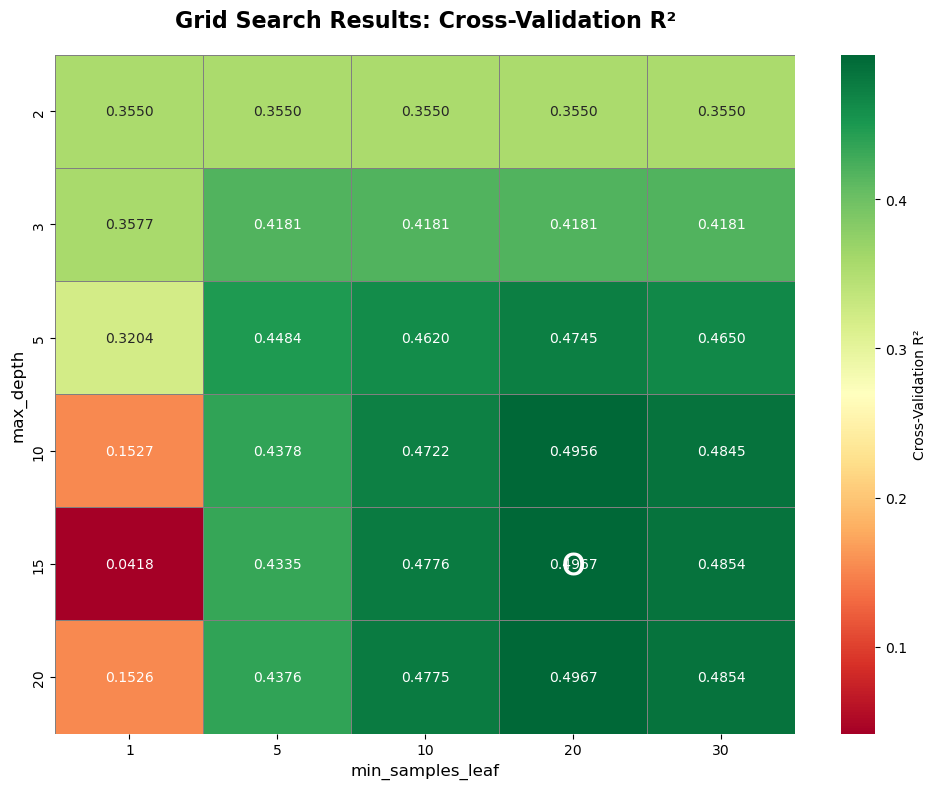


热力图已保存到 D:/MY_Learning/matbench-dielectric/figures/day03_grid_search_heatmap.png


In [45]:
# 创建热力图
plt.figure(figsize=(10, 8))

# 使用 seaborn 绘制
sns.heatmap(
    pivot_table, 
    annot=True,         # 显示数字
    fmt='.4f',          # 数字格式：保留 4 位小数
    cmap='RdYlGn',      # 颜色：红-黄-绿（绿色=高分）
    cbar_kws={'label': 'Cross-Validation R²'},  # 颜色条标签
    linewidths=0.5,     # 格子边框
    linecolor='gray'
)

# 设置标题和标签
plt.title('Grid Search Results: Cross-Validation R²', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('min_samples_leaf', fontsize=12)
plt.ylabel('max_depth', fontsize=12)

# 标注最佳点
best_depth = grid_search.best_params_['max_depth']
best_leaf = grid_search.best_params_['min_samples_leaf']

# 找到最佳点在表格中的位置
depth_idx = list(pivot_table.index).index(best_depth)
leaf_idx = list(pivot_table.columns).index(best_leaf)

# 画一个星号
plt.text(leaf_idx + 0.5, depth_idx + 0.5, 'o', 
         ha='center', va='center', fontsize=30, color='white')

plt.tight_layout()
plt.savefig('D:/MY_Learning/matbench-dielectric/figures/day03_grid_search_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n热力图已保存到 D:/MY_Learning/matbench-dielectric/figures/day03_grid_search_heatmap.png")

颜色含义 绿色表示 好 
        红色表示差  
        黄色表示一般   白色圈圈表示最佳组合 


对比不同策略的模型:

                   模型   训练R²   测试R²      差距  max_depth  min_samples_leaf
          Day 1: 默认参数 1.0000 0.0697  0.9303        NaN                 1
Day 2: 手动调优 (depth=5) 0.4701 0.4997 -0.0296        3.0                 1
          Day 3: 网格搜索 0.6499 0.5781  0.0718       15.0                20


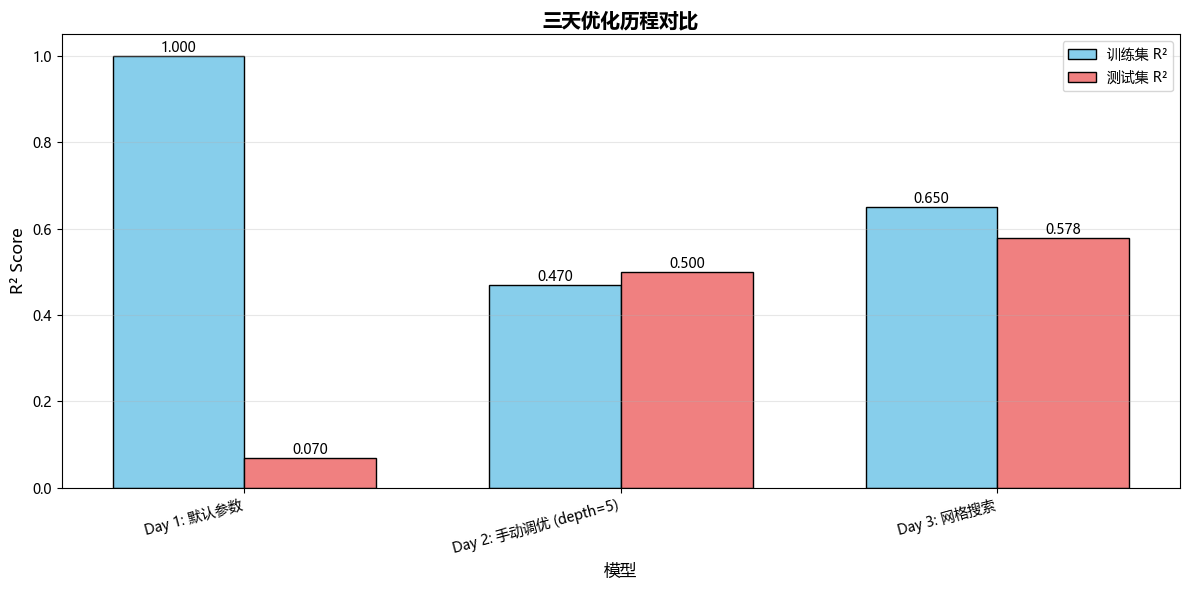

In [53]:
# 训练三个模型对比
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 换微软雅黑试试
plt.rcParams['axes.unicode_minus'] = False
print("\n对比不同策略的模型:\n")

# 模型 1：默认参数（Day 1）
dt_default = DecisionTreeRegressor(random_state=42)
dt_default.fit(X_train, y_train)

# 模型 2：Day 2 手动选的最佳 depth
# （假设 Day 2 你找到的最佳 depth 是 5）
dt_manual = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_manual.fit(X_train, y_train)

# 模型 3：今天网格搜索的最佳模型
dt_grid = grid_search.best_estimator_

# 创建对比表
models = {
    'Day 1: 默认参数': dt_default,
    'Day 2: 手动调优 (depth=5)': dt_manual,
    'Day 3: 网格搜索': dt_grid
}

comparison = []
for name, model in models.items():
    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)
    gap = train_r2 - test_r2
    
    comparison.append({
        '模型': name,
        '训练R²': f'{train_r2:.4f}',
        '测试R²': f'{test_r2:.4f}',
        '差距': f'{gap:.4f}',
        'max_depth': model.max_depth,
        'min_samples_leaf': model.min_samples_leaf
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

# 可视化对比
fig, ax = plt.subplots(figsize=(12, 6))

model_names = list(models.keys())
train_scores = [float(c['训练R²']) for c in comparison]
test_scores = [float(c['测试R²']) for c in comparison]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, train_scores, width, label='训练集 R²', 
               color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, test_scores, width, label='测试集 R²', 
               color='lightcoral', edgecolor='black')

# 添加数值标签
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('模型', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('三天优化历程对比', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('D:/MY_Learning/matbench-dielectric/figures/day03_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [54]:
import joblib
import os

# 创建 models 文件夹
os.makedirs('D:/MY_Learning/matbench-dielectric/models', exist_ok=True)

# 保存模型
model_path = 'D:/MY_Learning/matbench-dielectric/models/day03_best_tree.pkl'
joblib.dump(grid_search.best_estimator_, model_path)

print(f"\n最佳模型已保存到: {model_path}")
print(f"最佳参数: {grid_search.best_params_}")
print(f"测试集 R²: {test_r2:.4f}")

# 测试加载
loaded_model = joblib.load(model_path)
loaded_r2 = loaded_model.score(X_test, y_test)
print(f"\n验证：加载模型的测试集 R² = {loaded_r2:.4f}（应该和上面一样）")


最佳模型已保存到: D:/MY_Learning/matbench-dielectric/models/day03_best_tree.pkl
最佳参数: {'max_depth': 15, 'min_samples_leaf': 20}
测试集 R²: 0.5781

验证：加载模型的测试集 R² = 0.5781（应该和上面一样）


# Day 3 学习日志

## 我的最佳参数
通过网格搜索找到的最佳参数是：
- max_depth = 15
- min_samples_leaf = 20

为什么是这个组合？
看热力图，这个位置的 R² 最高

叶子门槛 min_samples_leaf 对防过拟合的效果比砍深度更稳
min_samples_leaf=1 时所有 depth 一起崩（CV R² < 0.35），这和 Day 2 不限制深度的现象一样

Fitting 5 folds for each of 30 candidates, totalling 150 fits
最佳参数: {'max_depth': 15, 'min_samples_leaf': 20}
最佳CV R²: 0.4967
测试集R²: 0.5781


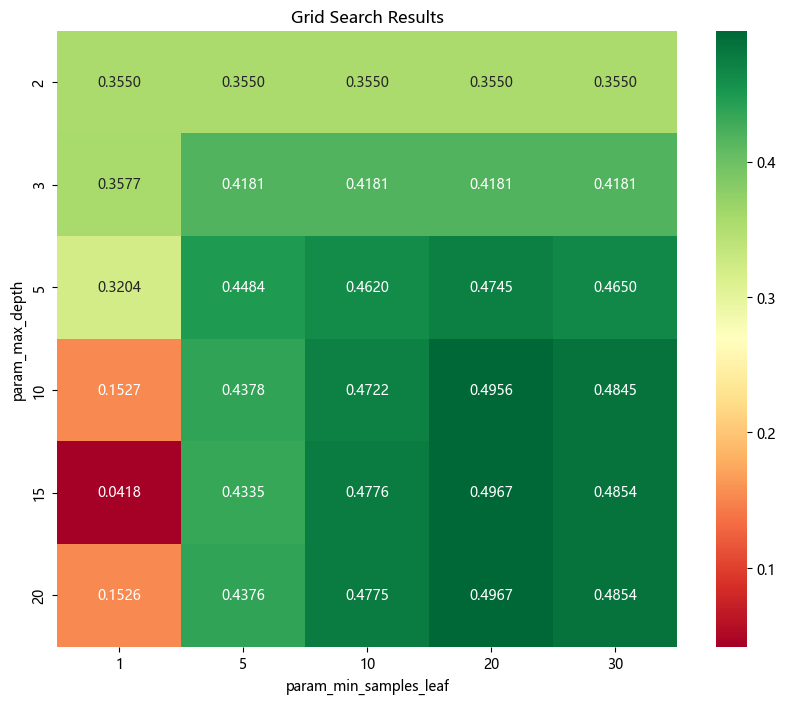

['D:/MY_Learning/matbench-dielectric/models/day03_best_tree.pkl']

In [55]:
#完整代码
# day03_grid_search.ipynb - 完整版

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# ========== 1. 数据准备 ==========
df = pd.read_csv('D:/MY_Learning/matbench-dielectric/data/dielectric_cleaned.csv')
X = df.drop('n_dielectric', axis=1)
y = np.log1p(df['n_dielectric'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ========== 2. 网格搜索 ==========
param_grid = {
    'max_depth': [2, 3, 5, 10, 15, 20],
    'min_samples_leaf': [1, 5, 10, 20 , 30]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

# ========== 3. 结果 ==========
print(f"最佳参数: {grid_search.best_params_}")
print(f"最佳CV R²: {grid_search.best_score_:.4f}")
print(f"测试集R²: {grid_search.score(X_test, y_test):.4f}")

# ========== 4. 热力图 ==========
results = pd.DataFrame(grid_search.cv_results_)
pivot = results.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_min_samples_leaf'
)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn')
plt.title('Grid Search Results')
os.makedirs('D:/MY_Learning/matbench-dielectric/figures', exist_ok=True)
plt.savefig('D:/MY_Learning/matbench-dielectric/figures/day03_grid_search_heatmap.png', dpi=150)
plt.show()

# ========== 5. 保存模型 ==========
os.makedirs('D:/MY_Learning/matbench-dielectric/models', exist_ok=True)
joblib.dump(grid_search.best_estimator_, 'D:/MY_Learning/matbench-dielectric/models/day03_best_tree.pkl')